# Historical Perfect-Foresight 2h BESS Benchmark

This notebook runs a deterministic full-horizon LP against historical half-hourly prices already saved by Phase 1.

It is a perfect-foresight arbitrage benchmark: the optimiser sees the whole price history before choosing charge/discharge. That makes it a useful upper benchmark, not a tradable strategy.


In [3]:
import sys, json
from pathlib import Path

# Bootstrap imports from the project root, then use the shared helper.
_ROOT_CANDIDATE = Path.cwd()
for candidate in [_ROOT_CANDIDATE, *_ROOT_CANDIDATE.parents]:
    if (candidate / "src").is_dir() and (candidate / "data").is_dir():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise RuntimeError("Could not find project root containing src/ and data/.")

from src.utils import find_project_root

PROJECT_ROOT = find_project_root(_ROOT_CANDIDATE)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import ASSET
from src.optimisation.perfect_foresight import solve_perfect_foresight

RAW = PROJECT_ROOT / 'data' / 'raw'
PROCESSED = PROJECT_ROOT / 'data' / 'processed'
PROCESSED.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Raw data dir: {RAW}')
print(f'Processed data dir: {PROCESSED}')


Project root: G:\My Drive\Research\bess_project
Raw data dir: G:\My Drive\Research\bess_project\data\raw
Processed data dir: G:\My Drive\Research\bess_project\data\processed


## Load Historical DA and System Prices

The benchmark uses the existing half-hourly Elexon day-ahead and system-price files.


In [4]:
def prepare_price_frame(df, price_col):
    df = df.copy()
    df['settlement_date'] = pd.to_datetime(df['settlement_date'])
    df = df.sort_values(['settlement_date', 'settlement_period']).reset_index(drop=True)
    df['timestamp_index'] = np.arange(len(df))
    return df[['settlement_date', 'settlement_period', 'timestamp_index', price_col]].rename(
        columns={price_col: 'price_gbp_mwh'}
    )

required = ['elexon_da_prices.parquet', 'elexon_sp_prices.parquet']
missing = [name for name in required if not (RAW / name).exists()]
if missing:
    raise FileNotFoundError(f'Missing raw files: {missing}. Run 01_data_pipeline.ipynb first.')

df_da_raw = pd.read_parquet(RAW / 'elexon_da_prices.parquet')
df_sp_raw = pd.read_parquet(RAW / 'elexon_sp_prices.parquet')

df_da = prepare_price_frame(df_da_raw, 'price_gbp_mwh')
df_sp = prepare_price_frame(df_sp_raw, 'system_price')

for label, df in [('DA', df_da), ('SP', df_sp)]:
    print(f'{label}: {len(df):,} rows, {df.settlement_date.min().date()} to {df.settlement_date.max().date()}')
    print(f'  settlement_period max: {df.settlement_period.max()}')
    print(f'  price min/mean/max: {df.price_gbp_mwh.min():.2f} / {df.price_gbp_mwh.mean():.2f} / {df.price_gbp_mwh.max():.2f} GBP/MWh')


DA: 36,240 rows, 2024-04-01 to 2026-04-25
  settlement_period max: 50
  price min/mean/max: -102.92 / 78.98 / 1352.90 GBP/MWh
SP: 36,240 rows, 2024-04-01 to 2026-04-25
  settlement_period max: 50
  price min/mean/max: -97.92 / 79.20 / 2900.00 GBP/MWh


## Battery Assumptions

Uses the configured 2-hour battery from `src.config.ASSET`.


In [5]:
asset_view = {
    k: ASSET[k]
    for k in [
        'power_mw', 'energy_mwh', 'duration_h', 'rte', 'eta_charge', 'eta_discharge',
        'soc_min_frac', 'soc_max_frac', 'soc_init_frac', 'vom_gbp_mwh'
    ]
    if k in ASSET
}
asset_view


{'power_mw': 100.0,
 'energy_mwh': 200.0,
 'duration_h': 2.0,
 'rte': 0.88,
 'eta_charge': 0.9381,
 'eta_discharge': 0.9381,
 'soc_min_frac': 0.1,
 'soc_max_frac': 0.9,
 'soc_init_frac': 0.5,
 'vom_gbp_mwh': 1.2}

## Full-Horizon Perfect-Foresight LP

The LP chooses charge, discharge, and SoC for every historical half-hour. Terminal SoC is constrained to equal initial SoC.


In [6]:
def run_one(label, df):
    print(f'Solving {label} perfect-foresight LP on {len(df):,} half-hours...')
    result = solve_perfect_foresight(df['price_gbp_mwh'].to_numpy(), ASSET, dt_h=0.5)
    horizon_years = len(df) * 0.5 / 8760.0

    dispatch = df.copy()
    dispatch['charge_mw'] = result.charge_mw
    dispatch['discharge_mw'] = result.discharge_mw
    dispatch['net_export_mw'] = result.discharge_mw - result.charge_mw
    dispatch['soc_mwh'] = result.soc_mwh[:-1]
    dispatch['cashflow_gbp'] = result.cashflow_gbp

    out_path = PROCESSED / f'perfect_foresight_{label.lower()}_dispatch.parquet'
    dispatch.to_parquet(out_path, index=False)

    summary = {
        'rows': int(len(df)),
        'start_date': str(df['settlement_date'].min().date()),
        'end_date': str(df['settlement_date'].max().date()),
        'price_min_gbp_mwh': float(df['price_gbp_mwh'].min()),
        'price_mean_gbp_mwh': float(df['price_gbp_mwh'].mean()),
        'price_max_gbp_mwh': float(df['price_gbp_mwh'].max()),
        'value_gbp': float(result.objective_gbp),
        'value_gbp_per_mw': float(result.objective_gbp / ASSET['power_mw']),
        'value_gbp_per_mw_year': float(result.objective_gbp / ASSET['power_mw'] / horizon_years),
        'horizon_years': float(horizon_years),
        'equivalent_cycles': float(result.cycles_equiv),
        'mean_daily_gbp': float(result.objective_gbp / df['settlement_date'].nunique()),
        'terminal_soc_mwh': float(result.soc_mwh[-1]),
        'dispatch_path': str(out_path),
    }
    print(json.dumps(summary, indent=2))
    return result, dispatch, summary

pf_da, dispatch_da, summary_da = run_one('DA', df_da)
pf_sp, dispatch_sp, summary_sp = run_one('SP', df_sp)


Solving DA perfect-foresight LP on 36,240 half-hours...
{
  "rows": 36240,
  "start_date": "2024-04-01",
  "end_date": "2026-04-25",
  "price_min_gbp_mwh": -102.92,
  "price_mean_gbp_mwh": 78.98129221854305,
  "price_max_gbp_mwh": 1352.9,
  "value_gbp": 7468376.959017647,
  "value_gbp_per_mw": 74683.76959017647,
  "value_gbp_per_mw_year": 36105.39854359525,
  "horizon_years": 2.0684931506849313,
  "equivalent_cycles": 1062.9821482233826,
  "mean_daily_gbp": 9891.890011943904,
  "terminal_soc_mwh": 100.0,
  "dispatch_path": "G:\\My Drive\\Research\\bess_project\\data\\processed\\perfect_foresight_da_dispatch.parquet"
}
Solving SP perfect-foresight LP on 36,240 half-hours...
{
  "rows": 36240,
  "start_date": "2024-04-01",
  "end_date": "2026-04-25",
  "price_min_gbp_mwh": -97.92,
  "price_mean_gbp_mwh": 79.2035681440846,
  "price_max_gbp_mwh": 2900.0,
  "value_gbp": 22028502.956402697,
  "value_gbp_per_mw": 220285.02956402698,
  "value_gbp_per_mw_year": 106495.41164353622,
  "horizon_ye

## Save Summary


In [7]:
summary = {
    'asset': {k: float(v) for k, v in asset_view.items()},
    'assumptions': {
        'dt_h': 0.5,
        'perfect_foresight': True,
        'terminal_soc_equals_initial': True,
    },
    'results': {
        'DA': summary_da,
        'SP': summary_sp,
    },
}

summary_path = PROCESSED / 'perfect_foresight_summary.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)

print(f'Saved: {summary_path}')
summary


Saved: G:\My Drive\Research\bess_project\data\processed\perfect_foresight_summary.json


{'asset': {'power_mw': 100.0,
  'energy_mwh': 200.0,
  'duration_h': 2.0,
  'rte': 0.88,
  'eta_charge': 0.9381,
  'eta_discharge': 0.9381,
  'soc_min_frac': 0.1,
  'soc_max_frac': 0.9,
  'soc_init_frac': 0.5,
  'vom_gbp_mwh': 1.2},
 'assumptions': {'dt_h': 0.5,
  'perfect_foresight': True,
  'terminal_soc_equals_initial': True},
 'results': {'DA': {'rows': 36240,
   'start_date': '2024-04-01',
   'end_date': '2026-04-25',
   'price_min_gbp_mwh': -102.92,
   'price_mean_gbp_mwh': 78.98129221854305,
   'price_max_gbp_mwh': 1352.9,
   'value_gbp': 7468376.959017647,
   'value_gbp_per_mw': 74683.76959017647,
   'value_gbp_per_mw_year': 36105.39854359525,
   'horizon_years': 2.0684931506849313,
   'equivalent_cycles': 1062.9821482233826,
   'mean_daily_gbp': 9891.890011943904,
   'terminal_soc_mwh': 100.0,
   'dispatch_path': 'G:\\My Drive\\Research\\bess_project\\data\\processed\\perfect_foresight_da_dispatch.parquet'},
  'SP': {'rows': 36240,
   'start_date': '2024-04-01',
   'end_date':

## Summary Comparison


In [8]:
summary_table = pd.DataFrame({
    'DA': summary_da,
    'SP': summary_sp,
}).T[[
    'start_date', 'end_date', 'price_min_gbp_mwh', 'price_mean_gbp_mwh', 'price_max_gbp_mwh',
    'value_gbp', 'value_gbp_per_mw', 'value_gbp_per_mw_year', 'horizon_years',
    'equivalent_cycles', 'mean_daily_gbp'
]]

summary_table


,start_date,end_date,price_min_gbp_mwh,price_mean_gbp_mwh,price_max_gbp_mwh,value_gbp,value_gbp_per_mw,value_gbp_per_mw_year,horizon_years,equivalent_cycles,mean_daily_gbp
DA,2024-04-01,2026-04-25,-102.92,78.981292,1352.9,7468376.959018,74683.76959,36105.398544,2.068493,1062.982148,9891.890012
SP,2024-04-01,2026-04-25,-97.92,79.203568,2900.0,22028502.956403,220285.029564,106495.411644,2.068493,2214.990143,29176.825108


## Dispatch Plot: Highest-Value DA Week


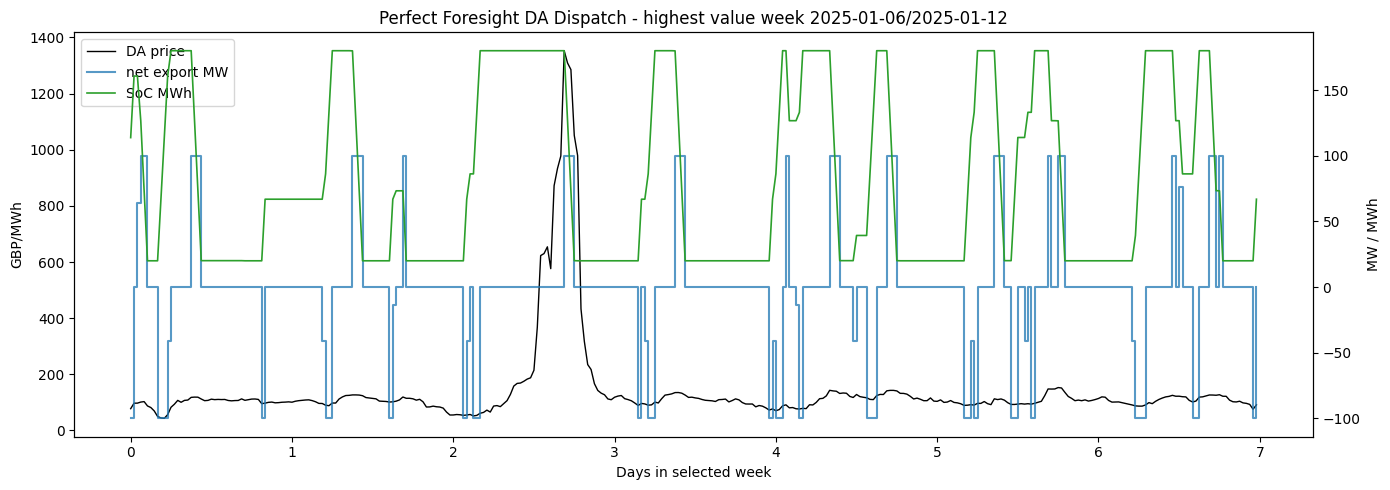

Saved: G:\My Drive\Research\bess_project\data\processed\perfect_foresight_da_high_value_week.png


In [9]:
weekly = dispatch_da.groupby(pd.to_datetime(dispatch_da['settlement_date']).dt.to_period('W'))['cashflow_gbp'].sum()
week = weekly.idxmax()
plot = dispatch_da.loc[pd.to_datetime(dispatch_da['settlement_date']).dt.to_period('W') == week].reset_index(drop=True)

x = np.arange(len(plot)) / 48.0
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(x, plot['price_gbp_mwh'], color='black', lw=1.0, label='DA price')
ax1.set_ylabel('GBP/MWh')

ax2 = ax1.twinx()
ax2.step(x, plot['net_export_mw'], where='post', color='tab:blue', alpha=0.75, label='net export MW')
ax2.plot(x, plot['soc_mwh'], color='tab:green', lw=1.2, label='SoC MWh')
ax2.set_ylabel('MW / MWh')

ax1.set_xlabel('Days in selected week')
ax1.set_title(f'Perfect Foresight DA Dispatch - highest value week {week}')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
fig.tight_layout()

plot_path = PROCESSED / 'perfect_foresight_da_high_value_week.png'
fig.savefig(plot_path, dpi=140, bbox_inches='tight')
plt.show()
print(f'Saved: {plot_path}')


## Output Files


In [10]:
for p in [
    PROCESSED / 'perfect_foresight_summary.json',
    PROCESSED / 'perfect_foresight_da_dispatch.parquet',
    PROCESSED / 'perfect_foresight_sp_dispatch.parquet',
    PROCESSED / 'perfect_foresight_da_high_value_week.png',
]:
    print(p, 'OK' if p.exists() else 'MISSING')


G:\My Drive\Research\bess_project\data\processed\perfect_foresight_summary.json OK
G:\My Drive\Research\bess_project\data\processed\perfect_foresight_da_dispatch.parquet OK
G:\My Drive\Research\bess_project\data\processed\perfect_foresight_sp_dispatch.parquet OK
G:\My Drive\Research\bess_project\data\processed\perfect_foresight_da_high_value_week.png OK
